# Excel IO Demo - OTC Curve Pricer

This notebook demonstrates the complete Excel workflow:
1. Read and display parsed inputs from `data/inputs.csv`
2. Run the pricer engine
3. Display outputs as dataframe and matplotlib charts
4. Write `data/outputs.csv` for Excel Power Query refresh

**Workflow:**
- User edits Inputs table in Excel
- User saves as `data/inputs.csv` (manual Save As CSV)
- Python reads inputs.csv + data/data_.csv, computes implied curve, writes `data/outputs.csv`
- Excel Outputs sheet uses Power Query to import outputs.csv and refresh on demand

In [1]:
# Configuration
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, date
import warnings
warnings.filterwarnings('ignore')


from genesis.uptick import client
client.authenticate("Rogy&chris02!!!")

import sys

PROJECT_ROOT = "/data/local/jupyterhub/userdata/OneBook/USG_Crude_Grades"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from tools import GetMarketData as gmd
from tools import MarketDataMainNilesh as market
from tools.GetMarketData import create_rolling_series_df


# Add src to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / "src"))

# File paths
DATA_DIR = project_root / "data"
HISTORICAL_PATH = DATA_DIR / "data_.csv"
INPUTS_PATH = DATA_DIR / "inputs.csv"
OUTPUTS_PATH = DATA_DIR / "outputs.csv"
CACHE_DIR = DATA_DIR / "cache"

# Import modules
from otc_pricer.parsing import parse_inputs_csv, compute_anchor_ages, extract_curve_families
from otc_pricer.covariance import get_covariance
from otc_pricer.inference import (
    compute_posterior,
    compute_implied_curve,
    compute_confidence_bands,
    compute_effective_weights,
    compute_anchor_noise
)
from otc_pricer.broker import load_broker_marks, compute_staleness_metrics
from otc_pricer.io_csv import write_outputs_csv

# Set seaborn style for better visualizations
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

2026-04-21 06:46:47,199 - Authenticating with UpTick as rbaddour
2026-04-21 06:46:47,288 - UpTick user authenticted as rbaddour


In [2]:

specific_df = pd.read_csv("/data/local/jupyterhub/userdata/OneBook/rbaddour/CreateDataCache/ProductDataCache_SpecificTenors_live.csv")
roll_sched_df = pd.read_excel("/data/local/jupyterhub/userdata/OneBook/rbaddour/CreateDataCache/roll_sched.xlsx")

product_tenor_dict = {
                      "wdf":"N3",                      
                      "wde":"N3"
                     }


tenors = ["A01:A15"]
start_date = "05-01-23"
end_date = (date.today() - timedelta(days=1)).strftime("%m-%d-%y")
roll_sched = "cl_roll"
roll_num = 2 


rolled_df = create_rolling_series_df(product_tenor_dict, tenors, start_date, end_date, roll_sched, roll_num,
                             specific_df, roll_sched_df)


In [3]:
import pandas as pd

def clean_inputs_df(inputs_df):
    df = inputs_df.copy()
    base = pd.Timestamp("1899-12-30")

    # 1) Fix the time column (Excel serial datetime -> pandas Timestamp)
    time_mask = df["time"].notna()
    df.loc[time_mask, "time"] = (
        base + pd.to_timedelta(df.loc[time_mask, "time"].astype(float), unit="D")
    )

    # 1b) Anchor rows: format time as '%Y-%m-%d %H:%M:%S'
    anchor_time_mask = df["section"].eq("anchor") & df["time"].notna()
    df.loc[anchor_time_mask, "time"] = (
        pd.to_datetime(df.loc[anchor_time_mask, "time"], errors="coerce")
        .dt.strftime("%Y-%m-%d %H:%M:%S")
    )

    # 2) Fix meta rows: asof_date and asof_time stored in `value`
    mask_date = df["key"].eq("asof_date") & df["value"].notna()
    mask_time = df["key"].eq("asof_time") & df["value"].notna()

    # asof_date → ISO date string
    df.loc[mask_date, "value"] = (
        base + pd.to_timedelta(df.loc[mask_date, "value"].astype(float), unit="D")
    ).dt.strftime("%Y-%m-%d")

    # asof_time → HH:MM:SS (no fractional seconds)
    df.loc[mask_time, "value"] = (
        pd.to_timedelta(df.loc[mask_time, "value"].astype(float), unit="D")
        .dt.components.apply(
            lambda x: f"{int(x.hours):02d}:{int(x.minutes):02d}:{int(x.seconds):02d}",
            axis=1
        )
    )

    return df


In [4]:
rolled_df.to_csv(str(HISTORICAL_PATH))

In [5]:
import numpy as np

inputs_df = (
    client.get("USG/WDF_Inputs", df=True)
    .replace(r'^\s*$', np.nan, regex=True)   # convert empty/whitespace to NaN
    .dropna(how='all')                       # drop rows where all columns are NaN
)

inputs_df = clean_inputs_df(inputs_df)
inputs_df

2026-04-21 06:47:10,824 - UpTick client is already authenticated


,section,key,month,value,time,abs_month,value_ws,active,Tenor
0,meta,curve_family,NaN,wdf,NaN,NaN,NaN,1.0,NaN
1,meta,asof_date,NaN,2026-04-10,NaN,NaN,NaN,NaN,NaN
2,meta,asof_time,NaN,13:33:04,NaN,NaN,NaN,NaN,NaN
3,param,cov_window_days,NaN,252,NaN,NaN,NaN,NaN,NaN
4,param,shrink_lambda,NaN,0.1,NaN,NaN,NaN,NaN,NaN
5,param,z,NaN,1.5,NaN,NaN,NaN,NaN,NaN
6,param,sigma_min,NaN,0.01,NaN,NaN,NaN,NaN,NaN
7,param,sigma_max,NaN,5,NaN,NaN,NaN,NaN,NaN
8,param,half_life_min,NaN,1200,NaN,NaN,NaN,NaN,NaN
9,base,base_ws,A01,63.03,NaN,May26,300.000,NaN,K6


In [6]:
pd.read_csv(str(INPUTS_PATH))

,section,key,month,value,time,active
0,meta,curve_family,NaN,wdf,NaN,NaN
1,meta,asof_date,NaN,2/10/2026,NaN,NaN
2,meta,asof_time,NaN,16:32,NaN,NaN
3,param,cov_window_days,NaN,252,NaN,NaN
4,param,shrink_lambda,NaN,0.1,NaN,NaN
5,param,z,NaN,1.5,NaN,NaN
6,param,sigma_min,NaN,0.01,NaN,NaN
7,param,sigma_max,NaN,5,NaN,NaN
8,param,half_life_min,NaN,1440,NaN,NaN
9,base,base_ws,A01,57.3573,NaN,NaN


## 1. Available Curve Families

List all available curve families in the historical dataset.

In [7]:
# List available curve families
families = extract_curve_families(str(HISTORICAL_PATH))
print(f"Found {len(families)} curve families in historical data:\n")
for family, tenors in sorted(families.items())[:15]:  # Show first 15
    print(f"  {family:20s} - {len(tenors)} tenors: {', '.join(tenors[:5])}{'...' if len(tenors) > 5 else ''}")
if len(families) > 15:
    print(f"\n  ... and {len(families) - 15} more")

Found 2 curve families in historical data:

  wde                  - 15 tenors: A01, A02, A03, A04, A05...
  wdf                  - 15 tenors: A01, A02, A03, A04, A05...


## 2. Parse and Display Inputs

Read `data/inputs.csv` and display all sections: meta, params, base curve, and anchors.

In [8]:
# Parse inputs.csv
inputs = parse_inputs_csv(inputs_df)

meta = inputs['meta']
params = inputs['params']
base_curve = inputs['base']
anchors = inputs['anchors']

print("✓ Loaded inputs.csv")
print(f"\nDEBUG - Base curve keys: {list(base_curve.keys())}")
print(f"DEBUG - Base curve A02: {base_curve.get('A02', 'NOT_FOUND')}")
print(f"DEBUG - Base curve A03: {base_curve.get('A03', 'NOT_FOUND')}")
print(f"DEBUG - Base curve A04: {base_curve.get('A04', 'NOT_FOUND')}")
print(f"\nDEBUG - Anchors parsed:")
for i, anchor in enumerate(anchors):
    print(f"  Anchor {i}: month={anchor.get('month')}, tenors={anchor.get('tenors', 'NOT_SET')}, value={anchor.get('value')}")

✓ Loaded inputs.csv

DEBUG - Base curve keys: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15']
DEBUG - Base curve A02: 42.02
DEBUG - Base curve A03: 43.0705
DEBUG - Base curve A04: 40.9695

DEBUG - Anchors parsed:
  Anchor 0: month=A00, tenors=['A00'], value=52.525
  Anchor 1: month=A00, tenors=['A00'], value=53.5755
  Anchor 2: month=A01, tenors=['A01'], value=44.64625
  Anchor 3: month=A01, tenors=['A01'], value=47.2725


### 2.1 Meta Information

In [9]:
# Display meta
meta_df = pd.DataFrame([meta])
print("Meta Information:")
print(meta_df.to_string(index=False))

Meta Information:
curve_family  asof_date asof_time
         wdf 2026-04-10  13:33:04


### 2.2 Parameters

In [10]:
# Display params
params_df = pd.DataFrame([params])
print("Parameters:")
print(params_df.to_string(index=False))

Parameters:
 cov_window_days  shrink_lambda  z  sigma_min  sigma_max  half_life_min
             252            0.1  1       0.01        5.0         1200.0


### 2.3 Base Curve

In [11]:
# Display base curve
base_df = pd.DataFrame(list(base_curve.items()), columns=['Tenor', 'Base Value'])
base_df = base_df.sort_values('Tenor')
print("Base Curve:")
print(base_df.to_string(index=False))

Base Curve:
Tenor  Base Value
  A01   63.030000
  A02   42.020000
  A03   43.070500
  A04   40.969500
  A05   38.868500
  A06   39.919000
  A07   42.020000
  A08   44.121000
  A09   43.070500
  A10   39.908495
  A11   36.746490
  A12   36.328391
  A13   35.910292
  A14   35.492193
  A15   33.951110


### 2.4 Anchors (with computed metrics)

In [12]:
meta

{'curve_family': 'wdf', 'asof_date': '2026-04-10', 'asof_time': '13:33:04'}

In [13]:
# Compute anchor ages and metrics
asof_date = meta.get('asof_date')
asof_time = meta.get('asof_time')
anchors_with_ages = compute_anchor_ages(anchors, asof_date, asof_time)

# Import parse_anchor_tenors for backward compatibility
from otc_pricer.parsing import parse_anchor_tenors

# Extract parameters for anchor noise computation
sigma_min = params.get('sigma_min', 0.5)
sigma_max = params.get('sigma_max', 5.0)
half_life_min = params.get('half_life_min', 120)

# Build anchors table with computed metrics
anchor_rows = []
for anchor in anchors_with_ages:
    # Handle both single tenors and strips
    # If 'tenors' field exists, use it; otherwise parse from 'month' field for backward compatibility
    if 'tenors' in anchor:
        anchor_tenors = anchor['tenors']
    else:
        # Backward compatibility: parse from month field
        anchor_tenors = parse_anchor_tenors(anchor.get('month', ''))
    tenor_display = '+'.join(anchor_tenors)
    
    anchor_price = anchor.get('value')
    anchor_time = anchor.get('time')
    age_minutes = anchor.get('age_minutes', 0)
    
    # Debug: Print anchor info for strips
    if len(anchor_tenors) > 1:
        print(f"DEBUG - Strip anchor: {tenor_display}")
        print(f"DEBUG - Anchor tenors: {anchor_tenors}")
        print(f"DEBUG - Base curve keys (first 5): {list(base_curve.keys())[:5]}")
        print(f"DEBUG - A02 in base_curve: {'A02' in base_curve}, value: {base_curve.get('A02', 'NOT_FOUND')}")
        print(f"DEBUG - A03 in base_curve: {'A03' in base_curve}, value: {base_curve.get('A03', 'NOT_FOUND')}")
        print(f"DEBUG - A04 in base_curve: {'A04' in base_curve}, value: {base_curve.get('A04', 'NOT_FOUND')}")
    
    # Compute shock (anchor - average base for strip)
    base_vals = [base_curve.get(t, 0.0) for t in anchor_tenors]
    if len(anchor_tenors) > 1:
        print(f"DEBUG - Base values retrieved: {base_vals}")
    base_avg = np.mean(base_vals)
    shock = anchor_price - base_avg if anchor_price is not None else None
    
    # Compute sigma (anchor noise)
    sigma_squared = compute_anchor_noise(age_minutes, sigma_min, sigma_max, half_life_min)
    sigma = np.sqrt(sigma_squared)
    
    anchor_rows.append({
        'Tenor': tenor_display,
        'Anchor Price': anchor_price,
        'Avg Base': base_avg,
        'Shock': shock,
        'Time': anchor_time,
        'Age (minutes)': age_minutes,
        'Sigma (noise)': sigma
    })

anchors_df = pd.DataFrame(anchor_rows)
if len(anchors_df) > 0:
    print("Active Anchors:")
    print(anchors_df.to_string(index=False))
else:
    print("No active anchors")

Active Anchors:
Tenor  Anchor Price  Avg Base     Shock                Time  Age (minutes)  Sigma (noise)
  A00      52.52500      0.00  52.52500 2026-03-13 07:56:24   40656.666667            5.0
  A00      53.57550      0.00  53.57550 2026-03-13 08:16:48   40636.266667            5.0
  A01      44.64625     63.03 -18.38375 2026-03-13 10:48:37   40484.450000            5.0
  A01      47.27250     63.03 -15.75750 2026-03-16 10:02:14   36210.833333            5.0


### 2.5 Strip Anchors

Strip anchors allow anchoring on averages of multiple periods (e.g., Q2-26 = A02+A03+A04). 
The system automatically:
- Computes the average base value across all tenors in the strip
- Applies the anchor constraint as a weighted average in the Bayesian inference
- Displays the strip notation (e.g., "A02+A03+A04") in the anchors table

**Example:** A strip anchor `A02+A03+A04` at price 200 means the average of A02, A03, and A04 should be 200.

## 3. Run Pricer

Execute the complete pricing pipeline.

In [14]:
# Extract parameters
curve_family = meta.get('curve_family')
asof_date = meta.get('asof_date')
cov_window_days = params.get('cov_window_days', 252)
shrink_lambda = params.get('shrink_lambda', 0.1)
z = params.get('z', 1.5)
sigma_min = params.get('sigma_min', 0.5)
sigma_max = params.get('sigma_max', 5.0)
half_life_min = params.get('half_life_min', 120)

print(f"Running pricer for curve family: {curve_family}")
print(f"As-of date: {asof_date}")

# Load/compute covariance
print("Loading covariance...")
cov, tenors = get_covariance(
    str(HISTORICAL_PATH),
    curve_family,
    window_days=cov_window_days,
    shrink_lambda=shrink_lambda,
    cache_dir=str(CACHE_DIR)
)
print(f"  ✓ Covariance matrix: {cov.shape}, {len(tenors)} tenors")

# Ensure base curve has all tenors
for tenor in tenors:
    if tenor not in base_curve:
        base_curve[tenor] = 0.0

# Compute anchor ages
asof_time = meta.get('asof_time')
anchors_with_ages = compute_anchor_ages(anchors, asof_date, asof_time)

# Run Bayesian inference
print("Running Bayesian inference...")
shock_vector, posterior_cov = compute_posterior(
    cov,
    anchors_with_ages,
    base_curve,
    tenors,
    sigma_min,
    sigma_max,
    half_life_min
)
print("  ✓ Posterior computed")

# Compute implied curve
implied_curve = compute_implied_curve(base_curve, shock_vector, tenors)

# Compute confidence bands
bands = compute_confidence_bands(posterior_cov, z)

# Compute effective weights
weights = compute_effective_weights(posterior_cov)

# Load broker marks
print("Loading broker marks...")
broker_marks = load_broker_marks(
    str(HISTORICAL_PATH),
    curve_family,
    asof_date,
    tenors
)

# Compute staleness metrics
staleness = compute_staleness_metrics(
    broker_marks,
    implied_curve,
    bands,
    tenors
)
print("  ✓ Broker marks and staleness metrics computed")

print("\n✓ Pricer completed successfully")

Running pricer for curve family: wdf
As-of date: 2026-04-10
Loading covariance...
Computing covariance for wdf (window=252 days)...
Cached covariance to /data/local/jupyterhub/userdata/OneBook/USG_Crude_Grades/OTC-Pricer/data/cache/cov_wdf_252.pkl
  ✓ Covariance matrix: (15, 15), 15 tenors
Running Bayesian inference...
  ✓ Posterior computed
Loading broker marks...
  ✓ Broker marks and staleness metrics computed

✓ Pricer completed successfully


## 4. Display Outputs DataFrame

In [15]:
# Build outputs dataframe
output_rows = []
for i, tenor in enumerate(tenors):
    row = {
        'month': tenor,
        'base': base_curve.get(tenor, 0.0),
        'broker': broker_marks.get(tenor) if broker_marks.get(tenor) is not None else None,
        'implied': implied_curve.get(tenor, 0.0),
        'dev': staleness[tenor]['dev'],
        'band': bands[i],
        'score': staleness[tenor]['score'],
        'flag': staleness[tenor]['flag'],
        'effective_weight': weights[i]
    }
    output_rows.append(row)

outputs_df = pd.DataFrame(output_rows)
print("Outputs DataFrame:")
display(outputs_df)

Outputs DataFrame:


,month,base,broker,implied,dev,band,score,flag,effective_weight
0,A01,63.030000,41.087,57.418723,-16.331723,2.027035,8.056953,RED,0.243376
1,A02,42.020000,40.874,39.372553,1.501447,1.359970,1.104029,OK,0.540681
2,A03,43.070500,39.140,41.374933,-2.234933,1.096465,2.038307,RED,0.831784
3,A04,40.969500,38.784,39.633418,-0.849418,0.990716,0.857378,OK,1.018830
4,A05,38.868500,42.593,37.862695,4.730305,0.980865,4.822585,RED,1.039397
5,A06,39.919000,42.593,38.916425,3.676575,0.777625,4.727955,RED,1.653712
6,A07,42.020000,42.593,41.079574,1.513426,0.760994,1.988749,YELLOW,1.726782
7,A08,44.121000,40.985,42.992225,-2.007225,0.734487,2.732825,RED,1.853667
8,A09,43.070500,40.985,42.544041,-1.559041,0.535036,2.913900,RED,3.493288
9,A10,39.908495,40.985,39.445435,1.539565,0.505880,3.043341,RED,3.907557


In [16]:
#This is th eoutputs _df table converted to WS
#on the outputs_df divide the base,implied,band,dev columns by .2101
ws_conversion_factor = .2101
outputs_df['base'] = outputs_df['base'] / ws_conversion_factor
outputs_df['implied'] = outputs_df['implied'] / ws_conversion_factor
outputs_df['band'] = outputs_df['band'] / ws_conversion_factor
outputs_df

,month,base,broker,implied,dev,band,score,flag,effective_weight
0,A01,300.000,41.087,273.292350,-16.331723,9.647951,8.056953,RED,0.243376
1,A02,200.000,40.874,187.399108,1.501447,6.472967,1.104029,OK,0.540681
2,A03,205.000,39.140,196.929714,-2.234933,5.218777,2.038307,RED,0.831784
3,A04,195.000,38.784,188.640735,-0.849418,4.715450,0.857378,OK,1.018830
4,A05,185.000,42.593,180.212734,4.730305,4.668562,4.822585,RED,1.039397
5,A06,190.000,42.593,185.228105,3.676575,3.701212,4.727955,RED,1.653712
6,A07,200.000,42.593,195.523911,1.513426,3.622056,1.988749,YELLOW,1.726782
7,A08,210.000,40.985,204.627438,-2.007225,3.495893,2.732825,RED,1.853667
8,A09,205.000,40.985,202.494244,-1.559041,2.546577,2.913900,RED,3.493288
9,A10,189.950,40.985,187.746003,1.539565,2.407805,3.043341,RED,3.907557


## 5. Visualizations

Matplotlib-only plots (no seaborn).

### 5.1 Base vs Implied vs Broker

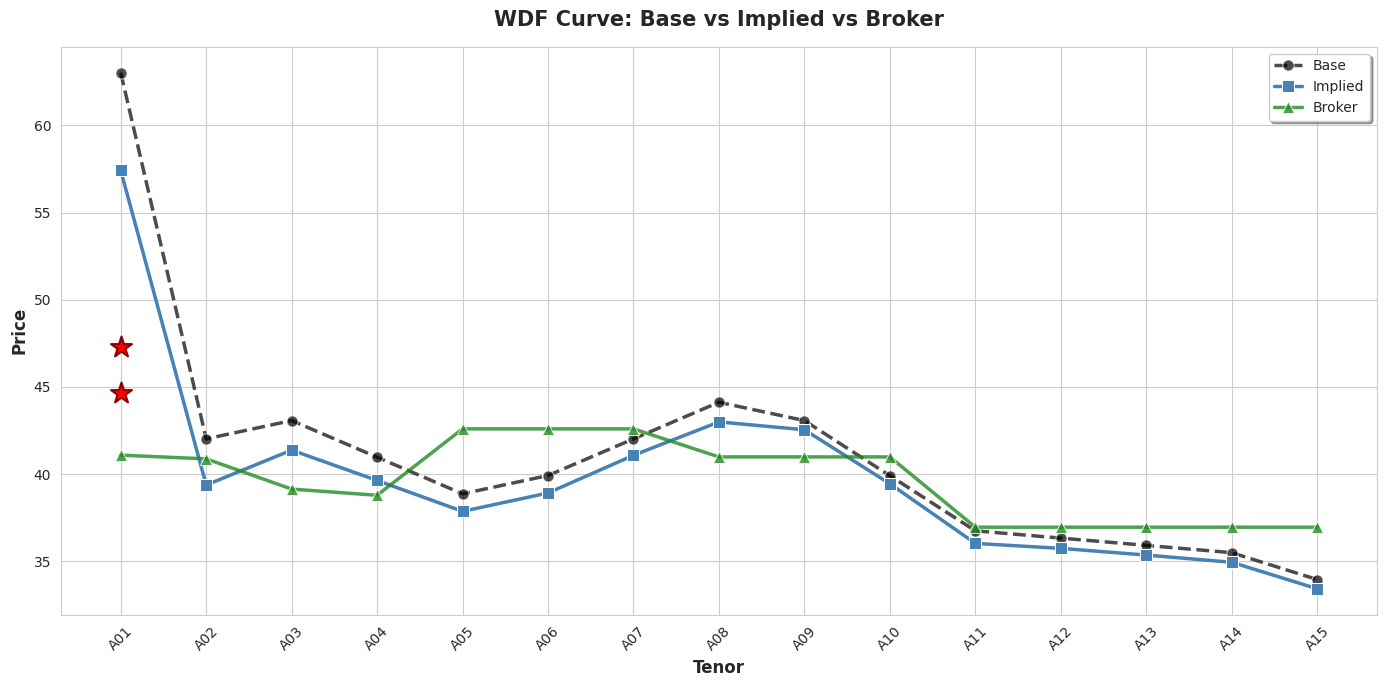

In [17]:
# Plot 1: Base vs Implied vs Broker
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data
plot_data = pd.DataFrame({
    'Tenor': tenors,
    'Base': [base_curve.get(t, 0.0) for t in tenors],
    'Implied': [implied_curve.get(t, 0.0) for t in tenors],
    'Broker': [broker_marks.get(t) if broker_marks.get(t) is not None else np.nan for t in tenors]
})

# Plot lines with seaborn styling
sns.lineplot(data=plot_data, x='Tenor', y='Base', ax=ax, label='Base', 
             linestyle='--', linewidth=2.5, marker='o', markersize=8, color='black', alpha=0.7)
sns.lineplot(data=plot_data, x='Tenor', y='Implied', ax=ax, label='Implied', 
             linewidth=2.5, marker='s', markersize=8, color='steelblue')
sns.lineplot(data=plot_data, x='Tenor', y='Broker', ax=ax, label='Broker', 
             linewidth=2.5, marker='^', markersize=8, color='forestgreen', alpha=0.8)

# Mark anchors
for anchor in anchors_with_ages:
    anchor_tenors = anchor.get('tenors', [anchor.get('month')])
    anchor_price = anchor.get('value')
    
    # For single tenors, plot at the tenor position
    # For strips, plot at the average tenor position (midpoint of x-axis indices)
    if len(anchor_tenors) == 1:
        tenor = anchor_tenors[0]
        if tenor in tenors:
            ax.scatter([tenor], [anchor_price], s=250, color='red', marker='*', 
                      zorder=5, edgecolors='darkred', linewidths=1.5, label='Anchors' if anchor == anchors_with_ages[0] else '')
    else:
        # Strip: plot at average position of tenors
        strip_tenors_in_plot = [t for t in anchor_tenors if t in tenors]
        if strip_tenors_in_plot:
            # Get x-axis positions (indices) for the strip tenors
            x_positions = [tenors.index(t) for t in strip_tenors_in_plot]
            avg_x = np.mean(x_positions)
            # Use the first tenor's label position for x-axis
            avg_tenor_label = strip_tenors_in_plot[len(strip_tenors_in_plot) // 2]
            ax.scatter([avg_tenor_label], [anchor_price], s=250, color='red', marker='*', 
                      zorder=5, edgecolors='darkred', linewidths=1.5, label='Anchors' if anchor == anchors_with_ages[0] else '')
            # Add annotation showing it's a strip
            ax.annotate(f"Strip: {'+'.join(anchor_tenors)}", 
                       xy=(avg_tenor_label, anchor_price),
                       xytext=(10, 10), textcoords='offset points',
                       fontsize=9, color='darkred', alpha=0.8,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Tenor', fontweight='bold')
ax.set_ylabel('Price', fontweight='bold')
ax.set_title(f'{curve_family.upper()} Curve: Base vs Implied vs Broker', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Confidence Bands

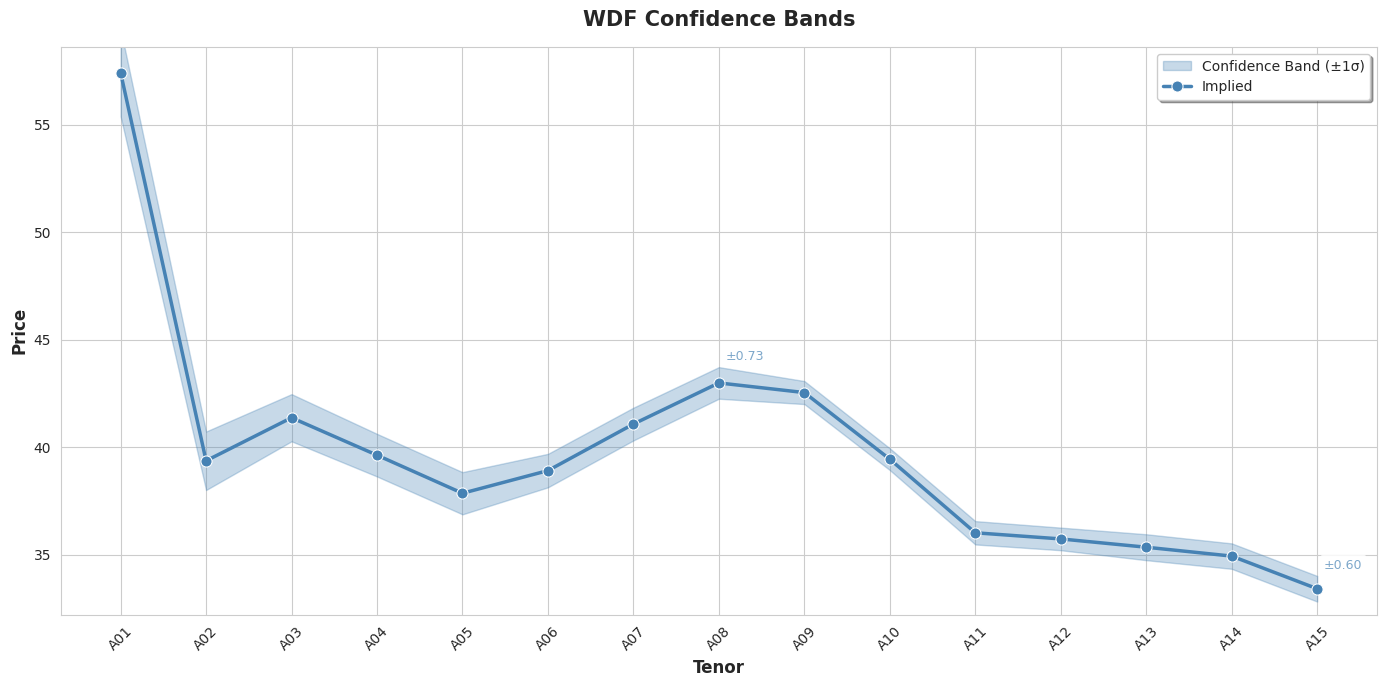

In [18]:
# Plot 2: Confidence bands with enhanced visualization
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data
plot_data = pd.DataFrame({
    'Tenor': tenors,
    'Implied': [implied_curve.get(t, 0.0) for t in tenors],
    'Upper': [implied_curve.get(t, 0.0) + bands[i] for i, t in enumerate(tenors)],
    'Lower': [implied_curve.get(t, 0.0) - bands[i] for i, t in enumerate(tenors)],
    'Band': bands
})

# Plot confidence band with seaborn styling
ax.fill_between(range(len(tenors)), plot_data['Lower'], plot_data['Upper'], 
                alpha=0.3, color='steelblue', label=f'Confidence Band (±{z}σ)', zorder=1)

# Plot implied curve
sns.lineplot(data=plot_data, x='Tenor', y='Implied', ax=ax, 
             linewidth=2.5, marker='o', markersize=8, color='steelblue', 
             label='Implied', zorder=2)

# Add band width annotations for key points
for i in [0, len(tenors)//2, len(tenors)-1]:
    if i < len(tenors):
        ax.annotate(f'±{bands[i]:.2f}', 
                   xy=(i, plot_data['Upper'].iloc[i]), 
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, color='steelblue', alpha=0.7,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Tenor', fontweight='bold')
ax.set_ylabel('Price', fontweight='bold')
ax.set_title(f'{curve_family.upper()} Confidence Bands', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.3 Staleness Scores (with flags)

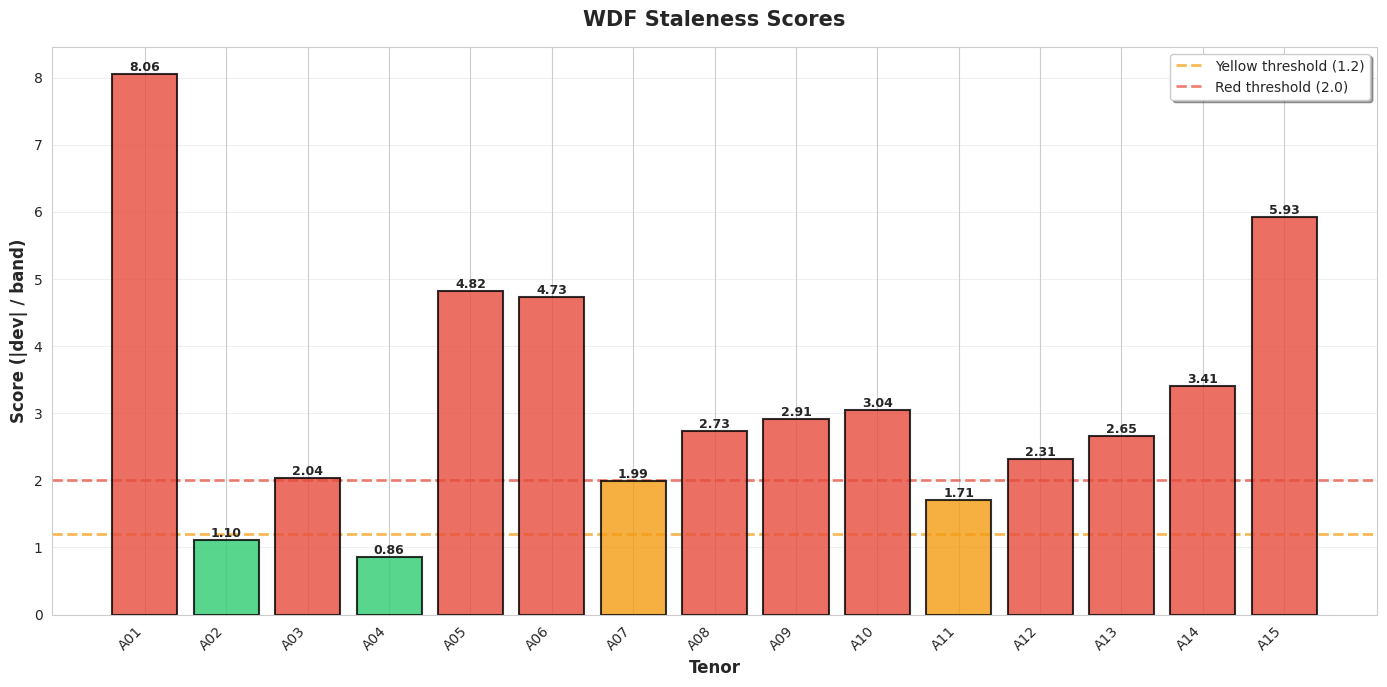

In [19]:
# Plot 3: Scores with color-coded flags using seaborn
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data
plot_data = pd.DataFrame({
    'Tenor': tenors,
    'Score': [staleness[t]['score'] if staleness[t]['score'] is not None else 0 for t in tenors],
    'Flag': [staleness[t]['flag'] for t in tenors]
})

# Color mapping
color_map = {
    'OK': '#2ecc71',      # Green
    'YELLOW': '#f39c12',  # Orange
    'RED': '#e74c3c',     # Red
    'N/A': '#95a5a6'      # Gray
}
colors = [color_map.get(flag, '#95a5a6') for flag in plot_data['Flag']]

# Create bar plot with seaborn styling
bars = ax.bar(range(len(tenors)), plot_data['Score'], color=colors, 
              alpha=0.8, edgecolor='black', linewidth=1.5, zorder=2)

# Add threshold lines with better styling
ax.axhline(y=1.2, color='#f39c12', linestyle='--', linewidth=2, 
          label='Yellow threshold (1.2)', zorder=1, alpha=0.7)
ax.axhline(y=2.0, color='#e74c3c', linestyle='--', linewidth=2, 
          label='Red threshold (2.0)', zorder=1, alpha=0.7)

# Add score values on bars
for i, (bar, score) in enumerate(zip(bars, plot_data['Score'])):
    if score > 0:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{score:.2f}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(tenors)))
ax.set_xticklabels(tenors, rotation=45, ha='right')
ax.set_xlabel('Tenor', fontweight='bold')
ax.set_ylabel('Score (|dev| / band)', fontweight='bold')
ax.set_title(f'{curve_family.upper()} Staleness Scores', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y', zorder=0)
plt.tight_layout()
plt.show()

## 6. Write Outputs CSV

Write `data/outputs.csv` so Excel can refresh via Power Query.

In [20]:
# Write outputs.csv
output_df = write_outputs_csv(
    str(OUTPUTS_PATH),
    tenors,
    base_curve,
    broker_marks,
    implied_curve,
    bands,
    weights,
    staleness,
    return_df=True
)

print(f"\n✓ Outputs written to {OUTPUTS_PATH}")
print("  Excel can now refresh the Outputs sheet via Power Query")

Wrote outputs to /data/local/jupyterhub/userdata/OneBook/USG_Crude_Grades/OTC-Pricer/data/outputs.csv

✓ Outputs written to /data/local/jupyterhub/userdata/OneBook/USG_Crude_Grades/OTC-Pricer/data/outputs.csv
  Excel can now refresh the Outputs sheet via Power Query


In [21]:
output_df

,month,base,broker,implied,dev,band,score,flag,effective_weight
0,A01,63.030000,41.087,57.418723,-16.331723,2.027035,8.056953,RED,0.243376
1,A02,42.020000,40.874,39.372553,1.501447,1.359970,1.104029,OK,0.540681
2,A03,43.070500,39.140,41.374933,-2.234933,1.096465,2.038307,RED,0.831784
3,A04,40.969500,38.784,39.633418,-0.849418,0.990716,0.857378,OK,1.018830
4,A05,38.868500,42.593,37.862695,4.730305,0.980865,4.822585,RED,1.039397
5,A06,39.919000,42.593,38.916425,3.676575,0.777625,4.727955,RED,1.653712
6,A07,42.020000,42.593,41.079574,1.513426,0.760994,1.988749,YELLOW,1.726782
7,A08,44.121000,40.985,42.992225,-2.007225,0.734487,2.732825,RED,1.853667
8,A09,43.070500,40.985,42.544041,-1.559041,0.535036,2.913900,RED,3.493288
9,A10,39.908495,40.985,39.445435,1.539565,0.505880,3.043341,RED,3.907557


In [22]:
client.publish('USG/WDF_implied_curve', output_df)

client.publish_df(f'usg/WDF_implied_curve', output_df)
print(output_df.to_string(index=False))
client.publish('USG/WDF_implied_curve_status', str(pd.Timestamp.today().strftime("%Y-%m-%d %H:%M:%S")))
# clear_output(wait=True)

month      base  broker   implied        dev     band    score   flag  effective_weight
  A01 63.030000  41.087 57.418723 -16.331723 2.027035 8.056953    RED          0.243376
  A02 42.020000  40.874 39.372553   1.501447 1.359970 1.104029     OK          0.540681
  A03 43.070500  39.140 41.374933  -2.234933 1.096465 2.038307    RED          0.831784
  A04 40.969500  38.784 39.633418  -0.849418 0.990716 0.857378     OK          1.018830
  A05 38.868500  42.593 37.862695   4.730305 0.980865 4.822585    RED          1.039397
  A06 39.919000  42.593 38.916425   3.676575 0.777625 4.727955    RED          1.653712
  A07 42.020000  42.593 41.079574   1.513426 0.760994 1.988749 YELLOW          1.726782
  A08 44.121000  40.985 42.992225  -2.007225 0.734487 2.732825    RED          1.853667
  A09 43.070500  40.985 42.544041  -1.559041 0.535036 2.913900    RED          3.493288
  A10 39.908495  40.985 39.445435   1.539565 0.505880 3.043341    RED          3.907557
  A11 36.746490  36.954 36.02479

True

In [23]:
def run_pricer_and_write_outputs(
    inputs_df,
    historical_path,
    output_path,
    cache_dir=None,
):
    """
    Run the pricer from inputs + historical data and write outputs CSV.

    Args:
        inputs_path: Path to inputs.csv (str or Path).
        historical_path: Path to historical data_.csv (str or Path).
        output_path: Path for outputs.csv (str or Path).
        cache_dir: Directory for covariance cache. Defaults to <inputs_dir>/cache.
    """

    # Parse inputs
    inputs = parse_inputs_csv(inputs_df)
    print(inputs)
    meta = inputs["meta"]
    params = inputs["params"]
    base_curve = inputs["base"].copy()
    anchors = inputs["anchors"]

    curve_family = meta.get("curve_family")
    asof_date = meta.get("asof_date")
    asof_time = meta.get("asof_time")
    cov_window_days = params.get("cov_window_days", 252)
    shrink_lambda = params.get("shrink_lambda", 0.1)
    z = params.get("z", 1.5)
    sigma_min = params.get("sigma_min", 0.5)
    sigma_max = params.get("sigma_max", 5.0)
    half_life_min = params.get("half_life_min", 120)

    # Load covariance
    cov, tenors = get_covariance(
        str(historical_path),
        curve_family,
        window_days=cov_window_days,
        shrink_lambda=shrink_lambda,
        cache_dir=str(cache_dir),
        use_cache = True
    )

    for tenor in tenors:
        if tenor not in base_curve:
            base_curve[tenor] = 0.0

    anchors_with_ages = compute_anchor_ages(anchors, asof_date, asof_time)

    shock_vector, posterior_cov = compute_posterior(
        cov,
        anchors_with_ages,
        base_curve,
        tenors,
        sigma_min,
        sigma_max,
        half_life_min,
    )

    implied_curve = compute_implied_curve(base_curve, shock_vector, tenors)
    bands = compute_confidence_bands(posterior_cov, z)
    weights = compute_effective_weights(posterior_cov)

    broker_marks = load_broker_marks(
        str(historical_path),
        curve_family,
        asof_date,
        tenors,
    )

    staleness = compute_staleness_metrics(
        broker_marks,
        implied_curve,
        bands,
        tenors,
    )

    output_df = write_outputs_csv(
        str(output_path),
        tenors,
        base_curve,
        broker_marks,
        implied_curve,
        bands,
        weights,
        staleness,
        return_df=True
    )
    return output_df


# Example: run with notebook paths and write outputs.csv
run_pricer_and_write_outputs(inputs_df, HISTORICAL_PATH, OUTPUTS_PATH)

{'meta': {'curve_family': 'wdf', 'asof_date': '2026-04-10', 'asof_time': '13:33:04'}, 'params': {'cov_window_days': 252, 'shrink_lambda': 0.1, 'z': 1, 'sigma_min': 0.01, 'sigma_max': 5.0, 'half_life_min': 1200.0}, 'base': OrderedDict([('A01', 63.03), ('A02', 42.02), ('A03', 43.0705), ('A04', 40.9695), ('A05', 38.8685), ('A06', 39.919), ('A07', 42.02), ('A08', 44.121), ('A09', 43.0705), ('A10', 39.908495), ('A11', 36.74649), ('A12', 36.328391), ('A13', 35.910292), ('A14', 35.492193), ('A15', 33.9511095)]), 'anchors': [{'key': 'anchor_ws', 'month': 'A00', 'tenors': ['A00'], 'value': 52.525, 'time': '2026-03-13 07:56:24'}, {'key': 'anchor_ws', 'month': 'A00', 'tenors': ['A00'], 'value': 53.5755, 'time': '2026-03-13 08:16:48'}, {'key': 'anchor_ws', 'month': 'A01', 'tenors': ['A01'], 'value': 44.64625, 'time': '2026-03-13 10:48:37'}, {'key': 'anchor_ws', 'month': 'A01', 'tenors': ['A01'], 'value': 47.2725, 'time': '2026-03-16 10:02:14'}]}
Loaded cached covariance for wdf (window=252)
Wrote 

,month,base,broker,implied,dev,band,score,flag,effective_weight
0,A01,63.030000,41.087,62.390064,-21.303064,0.684539,31.120289,RED,2.134043
1,A02,42.020000,40.874,41.617495,-0.743495,0.630631,1.178970,OK,2.514487
2,A03,43.070500,39.140,42.839522,-3.699522,0.587119,6.301148,RED,2.901002
3,A04,40.969500,38.784,40.825064,-2.041064,0.531676,3.838926,RED,3.537579
4,A05,38.868500,42.593,38.663737,3.929263,0.547679,7.174390,RED,3.333863
5,A06,39.919000,42.593,39.688398,2.904602,0.503566,5.768063,RED,3.943545
6,A07,42.020000,42.593,41.894763,0.698237,0.466008,1.498338,YELLOW,4.604832
7,A08,44.121000,40.985,44.063677,-3.078677,0.399594,7.704511,RED,6.262706
8,A09,43.070500,40.985,43.014022,-2.029022,0.346820,5.850365,RED,8.313664
9,A10,39.908495,40.985,39.839901,1.145099,0.345162,3.317566,RED,8.393691


In [ ]:
# Load all data files
import time
from IPython.display import clear_output

while True:
    inputs_df = (
        client.get("USG/WDF_Inputs", df=True)
        .replace(r'^\s*$', np.nan, regex=True)   # convert empty/whitespace to NaN
        .dropna(how='all')                       # drop rows where all columns are NaN
    )
    
    inputs_df = clean_inputs_df(inputs_df)
    
    wdf_implied_curve = run_pricer_and_write_outputs(inputs_df, HISTORICAL_PATH, OUTPUTS_PATH)
    
    client.publish_df(f'usg/wdf_implied_curve', wdf_implied_curve)
    print(wdf_implied_curve.to_string(index=False))
    client.publish('USG/wdf_implied_curve_status', str(pd.Timestamp.today().strftime("%Y-%m-%d %H:%M:%S")))
    clear_output(wait=True)
    time.sleep(10)
    


{'meta': {'curve_family': 'wdf', 'asof_date': '2026-04-10', 'asof_time': '13:33:04'}, 'params': {'cov_window_days': 252, 'shrink_lambda': 0.1, 'z': 1, 'sigma_min': 0.01, 'sigma_max': 5.0, 'half_life_min': 1200.0}, 'base': OrderedDict([('A01', 63.03), ('A02', 42.02), ('A03', 43.0705), ('A04', 40.9695), ('A05', 38.8685), ('A06', 39.919), ('A07', 42.02), ('A08', 44.121), ('A09', 43.0705), ('A10', 39.908495), ('A11', 36.74649), ('A12', 36.328391), ('A13', 35.910292), ('A14', 35.492193), ('A15', 33.9511095)]), 'anchors': [{'key': 'anchor_ws', 'month': 'A00', 'tenors': ['A00'], 'value': 52.525, 'time': '2026-03-13 07:56:24'}, {'key': 'anchor_ws', 'month': 'A00', 'tenors': ['A00'], 'value': 53.5755, 'time': '2026-03-13 08:16:48'}, {'key': 'anchor_ws', 'month': 'A01', 'tenors': ['A01'], 'value': 44.64625, 'time': '2026-03-13 10:48:37'}, {'key': 'anchor_ws', 'month': 'A01', 'tenors': ['A01'], 'value': 47.2725, 'time': '2026-03-16 10:02:14'}]}
Loaded cached covariance for wdf (window=252)
Wrote 